In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Модели
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


In [68]:
df = pd.read_csv('/Users/allikhankoshamet/Desktop/ml/BankChurners.csv')

In [69]:
df.columns.tolist()

['CLIENTNUM',
 'Attrition_Flag',
 'Customer_Age',
 'Gender',
 'Dependent_count',
 'Education_Level',
 'Marital_Status',
 'Income_Category',
 'Card_Category',
 'Months_on_book',
 'Total_Relationship_Count',
 'Months_Inactive_12_mon',
 'Contacts_Count_12_mon',
 'Credit_Limit',
 'Total_Revolving_Bal',
 'Avg_Open_To_Buy',
 'Total_Amt_Chng_Q4_Q1',
 'Total_Trans_Amt',
 'Total_Trans_Ct',
 'Total_Ct_Chng_Q4_Q1',
 'Avg_Utilization_Ratio',
 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']

In [70]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# ---------- 2. Быстрая разведка ----------
print("\nПервый взгляд:")
display(df.head())


Shape: (10127, 23)
Columns: ['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']

Первый взгляд:


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [71]:
df.isna().sum()


CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category                                 

In [72]:
duplicates = df.duplicated().sum()
print("Duplicates found:", duplicates)

Duplicates found: 0


In [55]:
def remove_outliers_iqr(data, cols):
    df_clean = data.copy()
    total_outliers = 0

    print("=== OUTLIER REPORT (IQR METHOD) ===\n")

    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Выбросы до фильтрации
        mask_outliers = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
        num_outliers = mask_outliers.sum()
        total_outliers += num_outliers
        
        print(f"{col}: {num_outliers} outliers found")
        
        # Фильтрация
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

    print(f"\nTotal outliers removed: {total_outliers}\n")
    
    return df_clean

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df = remove_outliers_iqr(df, numeric_cols).reset_index(drop=True)
print("Shape:", df.shape)

=== OUTLIER REPORT (IQR METHOD) ===

CLIENTNUM: 0 outliers found
Customer_Age: 2 outliers found
Dependent_count: 0 outliers found
Months_on_book: 385 outliers found
Total_Relationship_Count: 0 outliers found
Months_Inactive_12_mon: 308 outliers found
Contacts_Count_12_mon: 584 outliers found
Credit_Limit: 859 outliers found
Total_Revolving_Bal: 0 outliers found
Avg_Open_To_Buy: 467 outliers found
Total_Amt_Chng_Q4_Q1: 289 outliers found
Total_Trans_Amt: 575 outliers found
Total_Trans_Ct: 0 outliers found
Total_Ct_Chng_Q4_Q1: 195 outliers found
Avg_Utilization_Ratio: 0 outliers found
Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1: 1091 outliers found
Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2: 191 outliers found

Total outliers removed: 4946

Shape: (5181, 23)


In [73]:
cols_to_drop = [
    'CLIENTNUM',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
]

df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

In [74]:
print(df.dtypes)

Attrition_Flag               object
Customer_Age                  int64
Gender                       object
Dependent_count               int64
Education_Level              object
Marital_Status               object
Income_Category              object
Card_Category                object
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Avg_Open_To_Buy             float64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Amt               int64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
dtype: object


In [75]:
categorical_cols = [
    'Attrition_Flag',
    'Gender',
    'Education_Level',
    'Marital_Status',
    'Income_Category',
    'Card_Category'
]

numeric_cols = [
    'Customer_Age', 'Dependent_count', 'Months_on_book',
    'Total_Relationship_Count', 'Months_Inactive_12_mon',
    'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
    'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
    'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'
]

In [76]:
df['Attrition_Flag'] = df['Attrition_Flag'].map({
    'Existing Customer': 0,
    'Attrited Customer': 1})

In [77]:
df = pd.get_dummies(df, columns=[
    'Gender',
    'Education_Level',
    'Marital_Status',
    'Income_Category',
    'Card_Category'
], drop_first=True)

In [78]:
X = df.drop('Attrition_Flag', axis=1)
y = df['Attrition_Flag']

In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [80]:
results = []

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(title)
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

Decision Tree accuracy: 0.9343534057255676


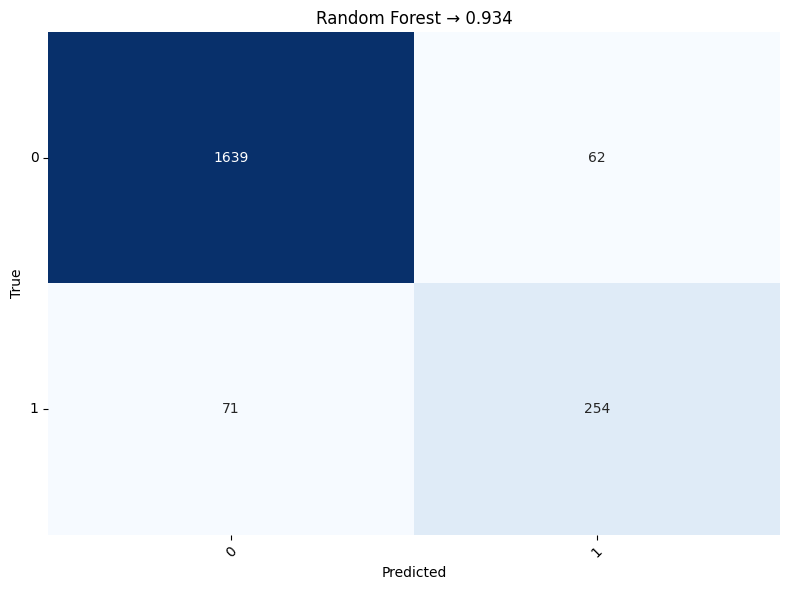

In [87]:
dt = DecisionTreeClassifier(max_depth=15, random_state =42)
dt.fit(X_train, y_train)
print("Decision Tree accuracy:", accuracy_score(y_test, dt.predict(X_test)))
acc = accuracy_score(y_test, dt.predict(X_test))
results.append({'Model': 'Random Forest', 'Accuracy': acc})
plot_cm(y_test, dt.predict(X_test), f'Random Forest → {acc:.3f}')

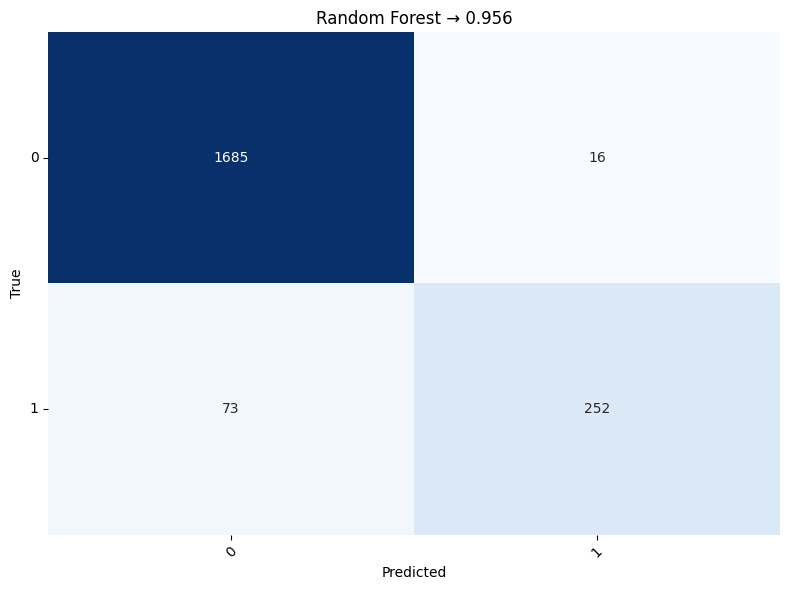

In [82]:
# 2. Random Forest
rf = RandomForestClassifier(n_estimators=1000, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
acc = accuracy_score(y_test, rf.predict(X_test))
results.append({'Model': 'Random Forest', 'Accuracy': acc})
plot_cm(y_test, rf.predict(X_test), f'Random Forest → {acc:.3f}')

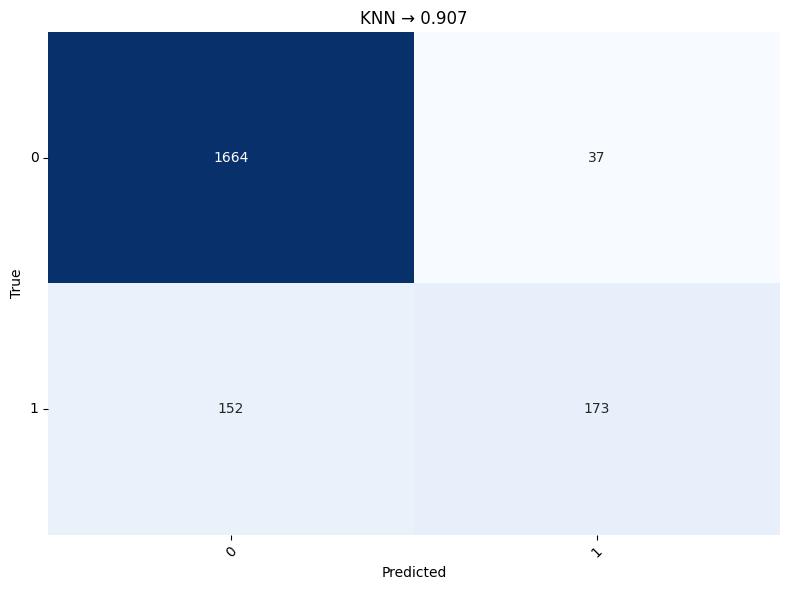

In [83]:
# 3. KNN
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)
acc = accuracy_score(y_test, knn.predict(X_test))
results.append({'Model': 'KNN', 'Accuracy': acc})
plot_cm(y_test, knn.predict(X_test), f'KNN → {acc:.3f}')

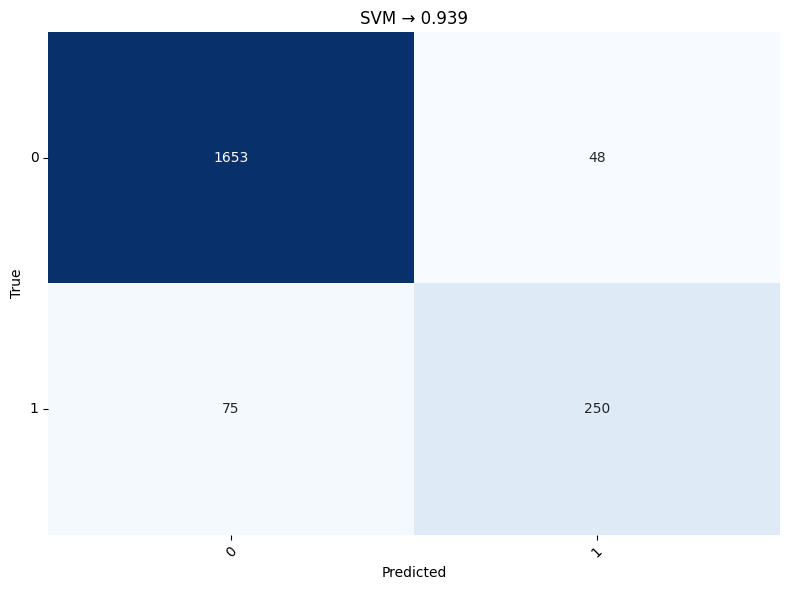

In [84]:
# 4. SVM
svm = SVC(C=10, kernel='rbf', random_state=42)
svm.fit(X_train, y_train)
acc = accuracy_score(y_test, svm.predict(X_test))
results.append({'Model': 'SVM', 'Accuracy': acc})
plot_cm(y_test, svm.predict(X_test), f'SVM → {acc:.3f}')


Hyperparameter Tuning → Random Forest
Best params: {'max_depth': 20, 'n_estimators': 600}
Accuracy improved from 0.9561 → 0.9576


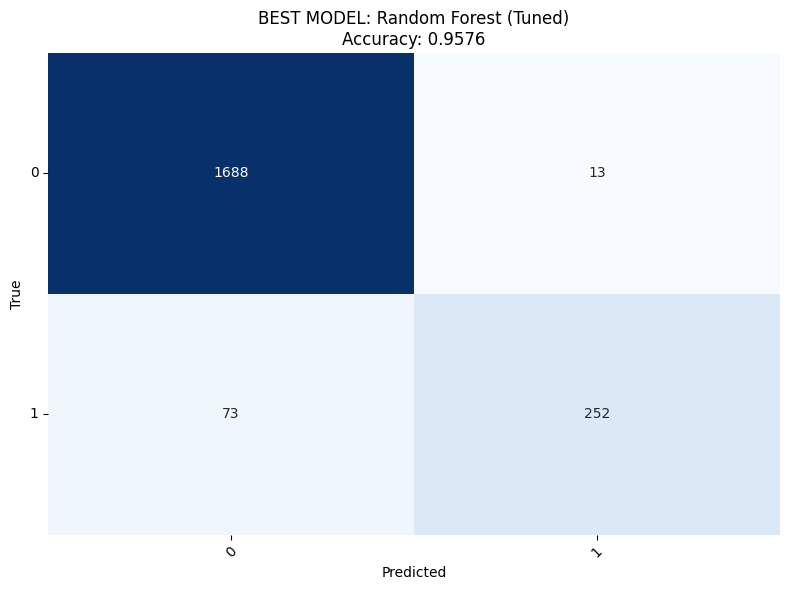

In [85]:
# Hyperparameter Tuning - Random Forest
print("\nHyperparameter Tuning → Random Forest")
grid = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                    {'n_estimators': [400, 600], 'max_depth': [20, None]},
                    cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)
best_rf = grid.best_estimator_
best_acc = accuracy_score(y_test, best_rf.predict(X_test))

print(f"Best params: {grid.best_params_}")
print(f"Accuracy improved from {accuracy_score(y_test, rf.predict(X_test)):.4f} → {best_acc:.4f}")

plot_cm(y_test, best_rf.predict(X_test), f'BEST MODEL: Random Forest (Tuned)\nAccuracy: {best_acc:.4f}')